In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Computer Vision
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image Processing
from PIL import Image

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("CUDA version used by PyTorch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Using Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.13.0+cu126
CUDA version used by PyTorch: 12.6
CUDA available: True
Using Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# DATASET PATHS

train_path = "./real_vs_fake/real-vs-fake/train"
valid_path = "./real_vs_fake/real-vs-fake/valid"
test_path = "./real_vs_fake/real-vs-fake/test"

print("Training Path :", train_path)
print("Validation Path :", valid_path)
print("Testing Path :", test_path)

print("\nChecking paths...")

print("Training exists :", os.path.exists(train_path))
print("Validation exists :", os.path.exists(valid_path))
print("Testing exists :", os.path.exists(test_path))

Training Path : ./real_vs_fake/real-vs-fake/train
Validation Path : ./real_vs_fake/real-vs-fake/valid
Testing Path : ./real_vs_fake/real-vs-fake/test

Checking paths...
Training exists : True
Validation exists : True
Testing exists : True


In [4]:
print("Training Path :", train_path)
print("Validation Path :", valid_path)
print("Testing Path :", test_path)

Training Path : ./real_vs_fake/real-vs-fake/train
Validation Path : ./real_vs_fake/real-vs-fake/valid
Testing Path : ./real_vs_fake/real-vs-fake/test


In [5]:
print(os.path.exists(train_path))
print(os.path.exists(valid_path))
print(os.path.exists(test_path))

True
True
True


In [6]:
# READ CSV FILES

train_df = pd.read_csv("./train.csv")
valid_df = pd.read_csv("./valid.csv")
test_df = pd.read_csv("./test.csv")

print("Train CSV shape :", train_df.shape)
print("Validation CSV shape :", valid_df.shape)
print("Test CSV shape :", test_df.shape)

print("\nTrain CSV:")
display(train_df.head())

print("\nValidation CSV:")
display(valid_df.head())

print("\nTest CSV:")
display(test_df.head())

Train CSV shape : (100000, 6)
Validation CSV shape : (20000, 6)
Test CSV shape : (20000, 6)

Train CSV:


,Unnamed: 0,original_path,id,label,label_str,path
0,0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,31355,1,real,train/real/31355.jpg
1,1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,02884,1,real,train/real/02884.jpg
2,2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,33988,1,real,train/real/33988.jpg
3,3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,53875,1,real,train/real/53875.jpg
4,4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,24149,1,real,train/real/24149.jpg



Validation CSV:


,Unnamed: 0,original_path,id,label,label_str,path
0,0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,20001,1,real,valid/real/20001.jpg
1,1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,11264,1,real,valid/real/11264.jpg
2,2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,19817,1,real,valid/real/19817.jpg
3,3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,46851,1,real,valid/real/46851.jpg
4,4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,10411,1,real,valid/real/10411.jpg



Test CSV:


,Unnamed: 0,original_path,id,label,label_str,path
0,0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,18233,1,real,test/real/18233.jpg
1,1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,54317,1,real,test/real/54317.jpg
2,2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,40155,1,real,test/real/40155.jpg
3,3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,12875,1,real,test/real/12875.jpg
4,4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,52543,1,real,test/real/52543.jpg


In [7]:
# CHECK CSV COLUMNS

print("Train columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(valid_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['Unnamed: 0', 'original_path', 'id', 'label', 'label_str', 'path']

Validation columns:
['Unnamed: 0', 'original_path', 'id', 'label', 'label_str', 'path']

Test columns:
['Unnamed: 0', 'original_path', 'id', 'label', 'label_str', 'path']


First 5 images:
['00000.jpg', '00002.jpg', '00003.jpg', '00006.jpg', '00009.jpg']
Image type:
<class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size:
(256, 256)
Original image:


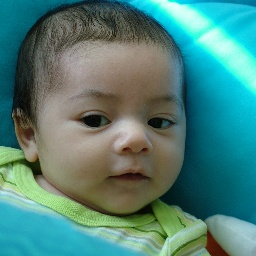

Resized image type:
<class 'PIL.Image.Image'>
Resized image size:
(128, 128)
Resized image:


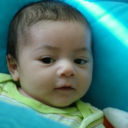

In [8]:
#Image Transformation

resize_transform = transforms.Compose([
    transforms.Resize((128, 128))
])

from PIL import Image

real_images = os.listdir(train_path + "/real")
print("First 5 images:")
print(real_images[:5])

#Open the first image
image = Image.open(train_path + "/real/" + real_images[0])

# Check the image type
print("Image type:")
print(type(image))

print("Image size:")
print(image.size)

print("Original image:")
display(image)

resized_image = resize_transform(image)

print("Resized image type:")
print(type(resized_image))

print("Resized image size:")
print(resized_image.size)

print("Resized image:")
display(resized_image)

In [9]:
#Converting the image to tensor

tensor_image = transforms.ToTensor()(resized_image)

print("Tensor type:")
print(type(tensor_image))

print("\nTensor shape:")
print(tensor_image.shape)

print("\nTensor data type:")
print(tensor_image.dtype)

print("\nMinimum pixel value:")
print(tensor_image.min())

print("\nMaximum pixel value:")
print(tensor_image.max())

Tensor type:
<class 'torch.Tensor'>

Tensor shape:
torch.Size([3, 128, 128])

Tensor data type:
torch.float32

Minimum pixel value:
tensor(0.)

Maximum pixel value:
tensor(1.)


In [10]:
  #Normalizing the image

normalized_image = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)(tensor_image)

print("Normalized image type:")
print(type(normalized_image))

print("\nNormalized image shape:")
print(normalized_image.shape)

print("\nNormalized image data type:")
print(normalized_image.dtype)

print("\nMinimum normalized value:")
print(normalized_image.min())

print("\nMaximum normalized value:")
print(normalized_image.max())

Normalized image type:
<class 'torch.Tensor'>

Normalized image shape:
torch.Size([3, 128, 128])

Normalized image data type:
torch.float32

Minimum normalized value:
tensor(-2.1179)

Maximum normalized value:
tensor(2.5877)


In [11]:
# Final Training Trannsformation

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# Testing Data Augmentation

augmented_image = train_transform(image)

print("Augmented image type:")
print(type(augmented_image))

print("\nAugmented image size:")
print(augmented_image.size)

print("\nAugmented image:")
display(augmented_image)

Augmented image type:
<class 'torch.Tensor'>

Augmented image size:
<built-in method size of Tensor object at 0x0000023858C4E6D0>

Augmented image:


tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [13]:
#Validation and test transformation

valid_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
#Load Dataset

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

print("Number of training images:", len(train_dataset))

print("\nClasses:")
print(train_dataset.classes)

print("\nClass to index:")
print(train_dataset.class_to_idx)

image, label = train_dataset[0]

print("\nImage type:")
print(type(image))

print("\nImage shape:")
print(image.shape)

print("\nImage data type:")
print(image.dtype)

print("\nLabel:")
print(label)

Number of training images: 100000

Classes:
['fake', 'real']

Class to index:
{'fake': 0, 'real': 1}

Image type:
<class 'torch.Tensor'>

Image shape:
torch.Size([3, 128, 128])

Image data type:
torch.float32

Label:
0


In [15]:
#Validation Dataset

valid_dataset = datasets.ImageFolder(
    root = valid_path,
    transform = valid_test_transform
)

print("Number of validation images:", len(valid_dataset))

print("\nClasses:")
print(valid_dataset.classes)

print("\nClass to index:")
print(valid_dataset.class_to_idx)

Number of validation images: 20000

Classes:
['fake', 'real']

Class to index:
{'fake': 0, 'real': 1}


In [16]:
#Test Dataset

test_dataset = datasets.ImageFolder(
    root = test_path,
    transform = valid_test_transform
)

print("Number of testing images:", len(test_dataset))

print("\nClasses:")
print(test_dataset.classes)

print("\nClass to index:")
print(test_dataset.class_to_idx)

Number of testing images: 20000

Classes:
['fake', 'real']

Class to index:
{'fake': 0, 'real': 1}


In [17]:
#DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Images shape:")
print(images.shape)

print("\nLabels shape:")
print(labels.shape)

print("\nImage data type:")
print(images.dtype)

print("\nLabels data type:")
print(labels.dtype)

Images shape:
torch.Size([32, 3, 128, 128])

Labels shape:
torch.Size([32])

Image data type:
torch.float32

Labels data type:
torch.int64


# **CNN Model**

In [18]:
class DeepfakeCNN(nn.Module):
  def __init__(self):
    super().__init__()

    #Convolution Layers
    self.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

    self.conv2 = nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
    )

    self.conv3 = nn.Conv2d(
        in_channels=64,
        out_channels=128,
        kernel_size=3,
        padding=1
    )

    self.pool = nn.MaxPool2d(kernel_size=2)

    self.relu = nn.ReLU()

    #Fully Connected Layer
    self.fc1 = nn.Linear(128 * 16 * 16, 128)
    self.fc2 = nn.Linear(128, 2)

    #Dropout
    self.dropout = nn.Dropout(0.5)


  def forward(self, x):

    #First convolution block
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    #Second convolution block
    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    #Third convolution block
    x = self.conv3(x)
    x = self.relu(x)
    x = self.pool(x)

    #Flatten
    x = torch.flatten(x, 1)

    #Fully Connected Layer
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)

    #Output Layer
    x = self.fc2(x)

    return x

In [19]:
#Final Model
model = DeepfakeCNN().to(device)

print(model)

DeepfakeCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [20]:
#Loss Function
criterion = nn.CrossEntropyLoss()

#Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
#Training Loop

from tqdm import tqdm

model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels in tqdm(train_loader):

  images = images.to(device)
  labels = labels.to(device)

  optimizer.zero_grad()

  outputs = model(images)

  loss = criterion(outputs, labels)

  loss.backward()

  optimizer.step()

  running_loss += loss.item()

  predicted = outputs.argmax(dim=1)

  total += labels.size(0)
  correct += (predicted == labels).sum().item()

average_loss = running_loss / len(train_loader)
accuracy = 100 * correct / total

print("Training loss:", average_loss)
print("Training accuracy:", accuracy)

100%|██████████| 3125/3125 [06:17<00:00,  8.29it/s]

Training loss: 0.5572895248365403
Training accuracy: 71.361


In [22]:
#Validation Loop
model.eval()

validation_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

  for images, labels in tqdm(valid_loader):

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    loss = criterion(outputs, labels)

    validation_loss += loss.item()

    predicted = outputs.argmax(dim=1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

average_loss = validation_loss / len(valid_loader)

validation_accuracy = 100 * correct / total

print("Validation loss:", average_loss)
print("Validation accuracy:", validation_accuracy)

100%|██████████| 625/625 [00:55<00:00, 11.31it/s]

Validation loss: 0.47046508536338805
Validation accuracy: 77.315


In [23]:
# Reset Model

model = DeepfakeCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model reset successfully")

Model reset successfully


In [24]:
# MODEL CHECKPOINT DIRECTORY

checkpoint_dir = "./checkpoints"

os.makedirs(checkpoint_dir, exist_ok=True)

print("Checkpoint directory:", checkpoint_dir)

Checkpoint directory: ./checkpoints


In [25]:
# Multi Epoch Training

from tqdm import tqdm
import os
import torch

# Number of epochs
num_epochs = 10

# Store training history
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Best validation accuracy seen so far
best_val_accuracy = 0.0

# Create checkpoint directory
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Path where the best model will be saved
best_model_path = os.path.join(
    checkpoint_dir,
    "best_deepfake_cnn.pth"
)

print("Training on:", device)
print("Checkpoint path:", best_model_path)

for epoch in range(num_epochs):

    print(f"\n{'=' * 50}")
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"{'=' * 50}")
    
    # TRAINING

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        running_train_loss += loss.item()

        # Calculate predictions
        predicted = outputs.argmax(dim=1)

        # Calculate accuracy
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Average training loss
    average_train_loss = (
        running_train_loss / len(train_loader)
    )

    # Training accuracy
    train_accuracy = (
        100 * train_correct / train_total
    )

    # VALIDATION
    
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in tqdm(
            valid_loader,
            desc="Validation"
        ):

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate validation loss
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            # Calculate predictions
            predicted = outputs.argmax(dim=1)

            # Calculate accuracy
            val_total += labels.size(0)
            val_correct += (
                (predicted == labels).sum().item()
            )

    # Average validation loss
    average_val_loss = (
        running_val_loss / len(valid_loader)
    )

    # Validation accuracy
    val_accuracy = (
        100 * val_correct / val_total
    )

    # SAVE TRAINING HISTORY

    train_losses.append(average_train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(average_val_loss)
    val_accuracies.append(val_accuracy)

    # SAVE BEST MODEL

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"\nBest model saved to: {best_model_path}"
        )

        print(
            f"New best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

    # PRINT RESULTS
    

    print("\nTraining Loss:",
          f"{average_train_loss:.4f}")

    print("Training Accuracy:",
          f"{train_accuracy:.2f}%")

    print("Validation Loss:",
          f"{average_val_loss:.4f}")

    print("Validation Accuracy:",
          f"{val_accuracy:.2f}%")

    print("Best Validation Accuracy:",
          f"{best_val_accuracy:.2f}%")

Training on: cuda
Checkpoint path: ./checkpoints\best_deepfake_cnn.pth

Epoch 1/10


Validation: 100%|██████████| 625/625 [00:47<00:00, 13.09it/s]



Best model saved to: ./checkpoints\best_deepfake_cnn.pth
New best validation accuracy: 76.94%

Training Loss: 0.5552
Training Accuracy: 71.70%
Validation Loss: 0.4849
Validation Accuracy: 76.94%
Best Validation Accuracy: 76.94%

Epoch 2/10


Validation: 100%|██████████| 625/625 [00:47<00:00, 13.06it/s]



Best model saved to: ./checkpoints\best_deepfake_cnn.pth
New best validation accuracy: 81.76%

Training Loss: 0.4551
Training Accuracy: 78.92%
Validation Loss: 0.4058
Validation Accuracy: 81.76%
Best Validation Accuracy: 81.76%

Epoch 3/10


...


Best model saved to: ./checkpoints\best_deepfake_cnn.pth
New best validation accuracy: 90.73%

Training Loss: 0.2686
Training Accuracy: 88.93%
Validation Loss: 0.2274
Validation Accuracy: 90.73%
Best Validation Accuracy: 90.73%

Epoch 9/10


Validation: 100%|██████████| 625/625 [00:47<00:00, 13.08it/s]



Training Loss: 0.2540
Training Accuracy: 89.70%
Validation Loss: 0.2576
Validation Accuracy: 89.74%
Best Validation Accuracy: 90.73%

Epoch 10/10


Validation: 100%|██████████| 625/625 [00:48<00:00, 13.02it/s]


Best model saved to: ./checkpoints\best_deepfake_cnn.pth
New best validation accuracy: 91.97%

Training Loss: 0.2419
Training Accuracy: 90.18%
Validation Loss: 0.1992
Validation Accuracy: 91.97%
Best Validation Accuracy: 91.97%


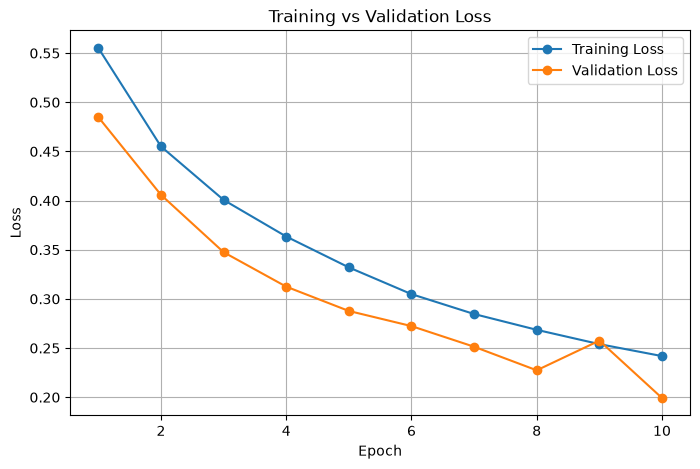

In [26]:
#Training and Validation Loss
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

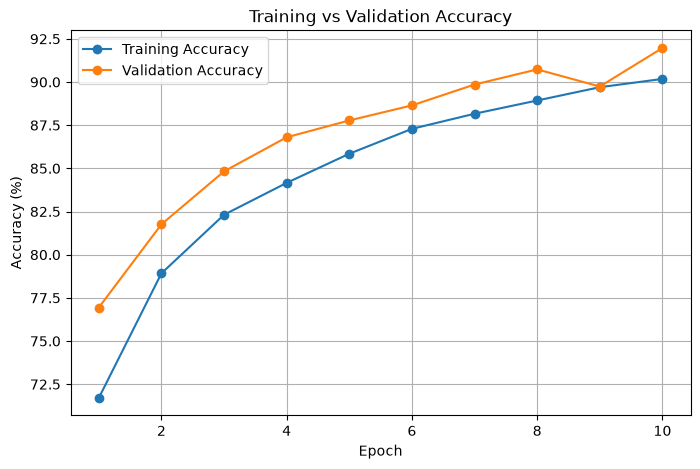

In [27]:
#Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [28]:
# Load Best Model

checkpoint_path = "./checkpoints/best_deepfake_cnn.pth"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model = model.to(device)

print("Best model loaded successfully")

Best model loaded successfully


In [40]:
#Test Evaluation

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    test_accuracy = 100.0 * correct/total

    print("Test accuracy:", test_accuracy)

Testing: 100%|██████████| 625/625 [00:47<00:00, 13.15it/s]

Test accuracy: 92.22


In [ ]:
#Collect Predictions for confusion Matrix

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc = "Collecting Predictions"):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions collected successfully")
print("Total predictions:", len(all_predictions))
print("Total labels:", len(all_labels))

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    all_labels,
    all_predictions,
    pos_label=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    pos_label=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    pos_label=0
)

print("Precision (%):", precision * 100)
print("Recall (%):", recall * 100)
print("F1 Score (%):", f1 * 100)

In [ ]:
from PIL import Image

image_path = "test_img.png"

image = Image.open(image_path).convert("RGB")

print("Image loaded successfully")
print("Original image size:", image.size)

In [ ]:
# Apply Test Transform

image_tensor = valid_test_transform(image)

print("Transformed image type:")
print(type(image_tensor))

print("\nTransformed image shape:")
print(image_tensor.shape)

In [ ]:
# Add Batch Dimension

image_tensor = image_tensor.unsqueeze(0)

print("Image tensor shape after adding batch dimension:")
print(image_tensor.shape)

In [ ]:
# Move Image to Device

image_tensor = image_tensor.to(device)

print("Image device:")
print(image_tensor.device)

In [ ]:
# Model Prediction

model.eval()

with torch.no_grad():

    outputs = model(image_tensor)

print("Model outputs:")
print(outputs)

In [ ]:
# Convert Outputs to Probabilities

probabilities = torch.softmax(outputs, dim=1)

print("Probabilities:")
print(probabilities)

In [ ]:
# Get Final Prediction

predicted_class = probabilities.argmax(dim=1).item()

print("Predicted class:", predicted_class)